# Using brain templates from TemplateFlow

In this example, we see how to fetch and use brain templates
from [TemplateFlow](https://www.templateflow.org/).

TemplateFlow allows for the retrieval of image files, annotations, and
metadata for various brain templates.
Specific files are accessed via the ``get`` function
by providing the ``template`` name
and filtering by file name 'entities'
such as resolution (``res``),
``suffix``, ``atlas``, hemisphere (``hemi``), ``space``,
description (``desc``)...

.. admonition:: Tips

  TemplateFlow files follow a [BIDS filename template](https://bids.neuroimaging.io/getting_started/folders_and_files/files.html#filename-template)
  and should more less be organized as [BIDS template](https://bids-specification.readthedocs.io/en/latest/derivatives/atlas.html).

If a search matches multiple files,
the function returns a list of all matching paths.

Available resources can be explored in the
[TemplateFlow browser](https://www.templateflow.org/browse/).

We first see how to fetch and use the Desikan-Killiany (DK) atlas
in order to make surface plots.

Then, we see how to get the proper template
for the Harvard-Oxford volumetric atlas.

.. admonition:: Datasets used in this example

    - `harvard_oxford_atlas`

    - The [Desikan-Killiany atlas](https://surfer.nmr.mgh.harvard.edu/fswiki/CorticalParcellation)


## Fetch DK Surface template




In [2]:
import templateflow.api as tflow

from nilearn.surface import SurfaceImage, load_surf_data

template = "fsaverage"

fetched_files = tflow.get(
    template,
    extension="surf.gii",
    suffix="pial",
)
print(fetched_files)

100%|██████████| 66.1k/66.1k [00:00<00:00, 342kB/s] 
100%|██████████| 271k/271k [00:00<00:00, 991kB/s] 
100%|██████████| 1.07M/1.07M [00:00<00:00, 3.06MB/s]
100%|██████████| 4.34M/4.34M [00:00<00:00, 7.17MB/s]
100%|██████████| 66.1k/66.1k [00:00<00:00, 1.04MB/s]
100%|██████████| 271k/271k [00:00<00:00, 1.39MB/s]
100%|██████████| 1.07M/1.07M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.34M/4.34M [00:05<00:00, 724kB/s] 

[PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-3k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-10k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-41k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-164k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-3k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-10k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-41k_pial.surf.gii'), PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-164k_pial.surf.gii')]


In this example, the Desikan-Killiany (DK) atlas is fetched.
DK is defined with reference
to the *FreeSurfer average* (fsaverage) template,
which is provided at multiple densities (number of vertices per hemisphere):
3k, 10k, 41k, 164k
Here, we build a SurfaceImage containing the labels for both hemispheres
for the 3k and 10k densities.



In [3]:
used_densities = ["3k", "10k"]
# uncomment the following line in case you want to see all densities
# used_densities = ["3k", "10k", "41k", "164k"]

desikan_dict = {}
for density in ["3k", "10k"]:
    mesh = {}
    data = {}
    for hemi in ["left", "right"]:
        mesh[hemi] = tflow.get(
            template,
            extension="surf.gii",
            suffix="pial",
            density=density,
            hemi=hemi[0].upper(),
        )

        desc = "curated" if density == "164k" else None
        roi_data = load_surf_data(
            tflow.get(
                template,
                atlas="Desikan2006",
                density=density,
                hemi=hemi[0].upper(),
                extension="label.gii",
                desc=desc,
            )
        )
        if density == "164k":
            roi_data[roi_data < 0] = 0

        data[hemi] = roi_data

    desikan_dict[density] = SurfaceImage(mesh=mesh, data=data)

100%|██████████| 6.79k/6.79k [00:00<00:00, 25.9MB/s]
100%|██████████| 6.79k/6.79k [00:00<00:00, 8.37MB/s]
100%|██████████| 9.61k/9.61k [00:00<00:00, 22.7MB/s]
100%|██████████| 9.52k/9.52k [00:00<00:00, 7.77MB/s]


In [ ]:
tpl = "MNI152NLin2009cAsym"

atlas_fname

PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-01_atlas-HOSPA_desc-th50_dseg.nii.gz')

## Plotting the DK atlas
To plot the DK atlas, we also fetch the lookup table (LUT) from TemplateFlow,
to map region indices to the original region names and colors.
We also use the background sulcal depth map
to add more detail to the surface plot.
To do this we map the density
to the corresponding fsaverage data that Nilearn can fetch directly.



[load_fsaverage_data] Dataset created in /Users/emdupre/nilearn_data/fsaverage4
[load_fsaverage_data] Downloading data from https://osf.io/gkqd5/download ...
[load_fsaverage_data]  ...done. (3 seconds, 0 min)

[load_fsaverage_data] Extracting data from /Users/emdupre/nilearn_data/fsaverage4/70c52c9f064022a30aee9395723e66be/download...
[load_fsaverage_data] .. done.

[load_fsaverage_data] Dataset directory found: /Users/emdupre/nilearn_data/fsaverage4


/var/folders/_h/5_yjn8t51cs21zb_j5p6sqc00000gq/T/ipykernel_94760/98505078.py:27: RuntimeWarning: Meshes are not identical but have compatible number of vertices.
  plot_surf_roi(


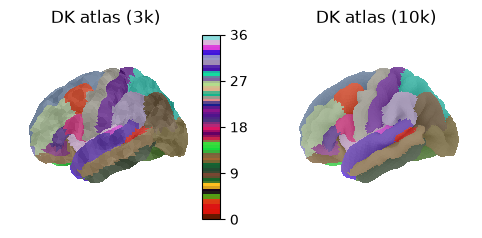

In [6]:
import matplotlib.pyplot as plt

from nilearn.datasets import load_fsaverage_data
from nilearn.plotting import plot_surf_roi, show

_, axes = plt.subplots(1, 2, subplot_kw={"projection": "3d"})

fs_density = {
    "3k": "fsaverage4",
    "10k": "fsaverage5",
    "41k": "fsaverage6",
    "164k": "fsaverage",
}

lut = tflow.get(
    template,
    atlas="Desikan2006",
    suffix="dseg",
    extension="tsv",
)

for ax, density in zip(axes, ["3k", "10k"], strict=True):
    desikan = desikan_dict[density]
    sulcal_depth_map = load_fsaverage_data(
        mesh=fs_density[density], data_type="sulcal"
    )
    plot_surf_roi(
        roi_map=desikan,
        cmap=lut,
        bg_map=sulcal_depth_map,
        bg_on_data=True,
        title=f"DK atlas ({density})",
        axes=ax,
    )
    if density == "10k":
        ax._colorbars[0].remove()

show()

## Getting the right template for volumetric atlases
The template used by nilearn to plot volumetric images is ICBM152 2009,
release a.
However, some atlases are defined on different templates,
this is the case for the Harvard-Oxford atlas.
This can lead to some imprecisions
when plotting volumetric atlases, with regions encompassing non-brain areas.



[fetch_atlas_harvard_oxford] Dataset directory found: /Users/emdupre/nilearn_data/fsl


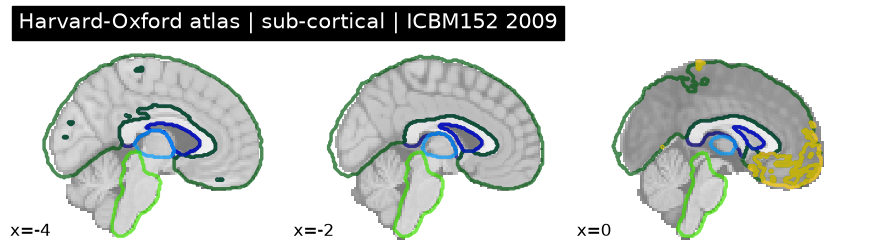

In [7]:
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.plotting import plot_roi

plotting_params = {
    "view_type": "contours",
    "display_mode": "x",
    "cut_coords": [-4, -2, 0],
    "black_bg": False,
}

harvard_oxford_sub = fetch_atlas_harvard_oxford("sub-maxprob-thr25-1mm")


plot_roi(
    harvard_oxford_sub.filename,
    title="Harvard-Oxford atlas | sub-cortical | ICBM152 2009",
    **plotting_params,
)

This is because the template of the Harvard-Oxford atlas is:



In [8]:
print(f"Harvard-Oxford atlas template: {harvard_oxford_sub.template}")

Harvard-Oxford atlas template: MNI152NLin6Asym


## Getting a template
If you want to visualize the Harvard-Oxford atlas
on the template it was originally defined,
you can get it from TemplateFlow.
This template is the default template used by FSL,
and its unique identifier within TemplateFlow
is`MNI152NLin6Asym`.



100%|██████████| 3.29M/3.29M [00:05<00:00, 645kB/s] 


MNI152NLin6Asym_template_img=PosixPath('/Users/emdupre/Library/Caches/templateflow/tpl-MNI152NLin6Asym/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz')


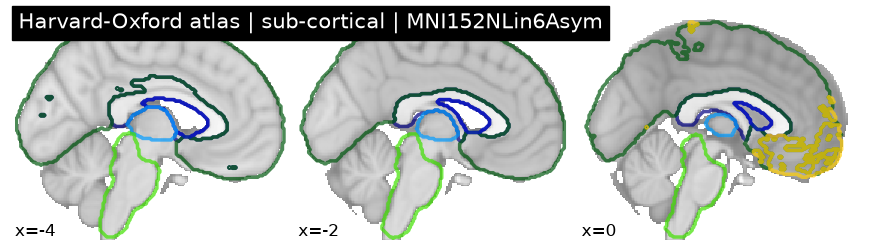

In [9]:
template = "MNI152NLin6Asym"
resolution = "01"

MNI152NLin6Asym_template_img = tflow.get(
    template,
    resolution=resolution,
    suffix="T1w",
    desc="brain",  # Set desc-brain to get the skull-stripped variant
    extension="nii.gz",
)

print(f"{MNI152NLin6Asym_template_img=}")

plot_roi(
    harvard_oxford_sub.filename,
    title="Harvard-Oxford atlas | sub-cortical | MNI152NLin6Asym",
    bg_img=MNI152NLin6Asym_template_img,
    **plotting_params,
)

show()

Note that we can also get the same atlas on different templates to compare

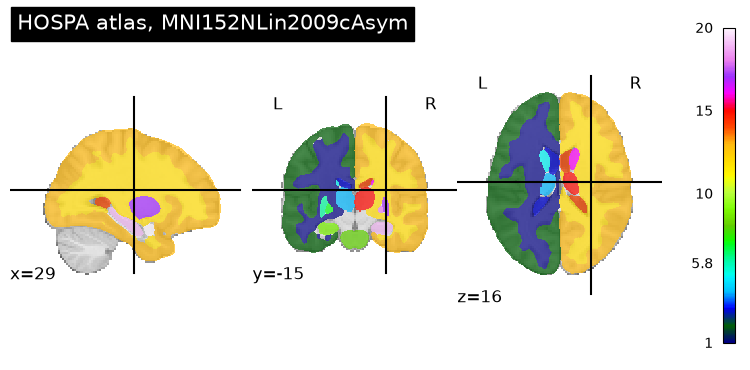

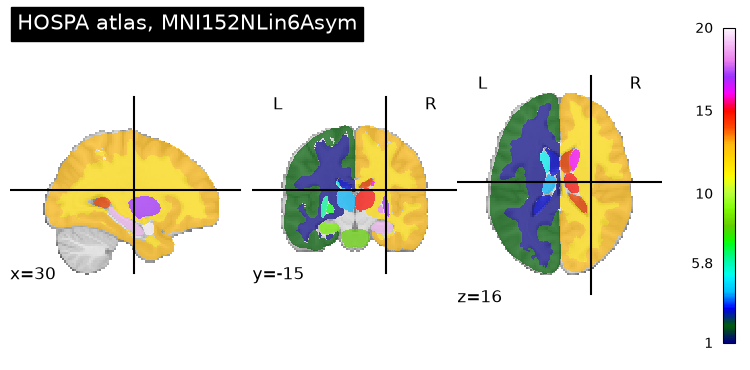

In [31]:
from nilearn import plotting

templates = ["MNI152NLin2009cAsym", "MNI152NLin6Asym"]

for tpl in templates:
    atlas_fname = tflow.get(
        tpl,
        atlas="HOSPA",
        suffix="dseg",
        resolution=1,
        desc="th50"
    )
    plotting.plot_roi(
        atlas_fname,
        title=f'HOSPA atlas, {tpl}',
        display_mode='ortho',
        draw_cross=True,
        # bg_img=None,
        colorbar=True,
    )

## Working with a custom atlas

Finally, we will show how to integrate a custom atlas with Nilearn masker objects.
In this case, we will use the HCP Glasser parcellation, which is not distributed with `templateflow` due to HCP terms.
For this, we will use the `hcp_utils` library.

Note that this section is largely adapted from [a Nilearn example](https://nilearn.github.io/stable/auto_examples/07_advanced/plot_surface_image_and_maskers.html#connectivity-with-a-surface-atlas-and-surfacelabelsmasker).

In [98]:
import hcp_utils as hcp
from nilearn.surface import InMemoryMesh, PolyMesh

# define the mesh for the left and right hemispheres
left_coords, left_faces = hcp.mesh["pial_left"]
right_coords, right_faces = hcp.mesh["pial_right"]

mesh = PolyMesh(
    left=InMemoryMesh(left_coords, left_faces),
    right=InMemoryMesh(right_coords, right_faces),
)

In [ ]:
from nilearn.surface import SurfaceImage

# we use the Multi Modal Parcellation (MMP) provided in hcp_utils
# https://rmldj.github.io/hcp-utils/parcellation_labels.html
parc = hcp.mmp
right_data = hcp.right_cortex_data(parc.map_all)
left_data = hcp.left_cortex_data(parc.map_all)

data = {
    "left": left_data,
    "right": right_data,
}

labels_image = SurfaceImage(mesh=mesh, data=data)

In [ ]:
import pandas as pd

# we define a BIDS-formatted Look Up Table (LUT)
# this will follow the structure shown here :
# https://bids-specification.readthedocs.io/en/stable/derivatives/imaging.html#atlas-tabular-data 

lut = pd.DataFrame(parc.labels.values(), index=parc.labels.keys(), columns=["name"])
lut.iloc[0] = "Background"
lut['color'] = parc.rgba.values()
lut['index'] = lut.index
lut.head()

,name,color,index
0,Background,"[0.0, 0.0, 0.0, 0.0]",0
1,L_V1,"[0.262745, 0.0392157, 1.0, 1.0]",1
2,L_MST,"[0.192157, 0.356863, 0.498039, 1.0]",2
3,L_V6,"[0.192157, 0.333333, 0.658824, 1.0]",3
4,L_V2,"[0.0509804, 0.2, 0.929412, 1.0]",4


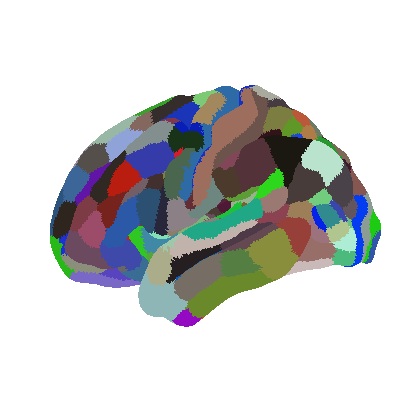

In [101]:
from nilearn.plotting import plot_surf_roi, show

plot_surf_roi(surf_mesh=mesh, roi_map=labels_image, cmap=lut, colorbar=False)
show()

In [103]:
from nilearn.maskers import SurfaceLabelsMasker

surface_lbls_masker = SurfaceLabelsMasker(labels_img=labels_image, lut=lut)
report = surface_lbls_masker.fit()
report

,"labels_img labels_img: :obj:`~nilearn.surface.SurfaceImage` objectRegion definitions, as one image of labels.The data for each hemisphereis of shape (n_vertices_per_hemisphere, n_regions).","<SurfaceImage (64984,)>"
,"labels labels: :obj:`list` of :obj:`str`, default=NoneMutually exclusive with ``lut``.Labels corresponding to the labels image.This is used to improve reporting quality if provided.""Background"" can be included in this list of labelsto denote which values in the image should be consideredbackground value... warning:: If the labels are not be consistent with the label values provided through ``labels_img``, excess labels will be dropped, and missing labels will be labeled ``'unknown'``.",None
,"lut lut: :obj:`pandas.DataFrame` or :obj:`str` or :obj:`pathlib.Path` to a TSV file or None, default=NoneMutually exclusive with ``labels``.Act as a look up table (lut)with at least columns 'index' and 'name'.Formatted according to 'dseg.tsv' format from`BIDS `_... warning:: If a region exist in the atlas image but is missing from its associated LUT, a new entry will be added to the LUT during fit with the name ""unknown"". Conversely, if regions listed in the LUT do not exist in the associated atlas image, they will be dropped from the LUT during fit.",...s x 3 columns]
,"background_label background_label: :obj:`int` or :obj:`float`, default=0Label used in labels_img to represent background... warning:: This value must be consistent with label values and image provided.",0
,"mask_img mask_img: :obj:`~nilearn.surface.SurfaceImage` object or None, default=NoneMask to apply to labels_img before extracting signals. Defines the overall area of the brain to consider. The data for each hemisphere is of shape (n_vertices_per_hemisphere, n_regions).",None
,"smoothing_fwhm smoothing_fwhm: :obj:`float` or :obj:`int` or None, optional.If `smoothing_fwhm` is not `None`,it gives the :term:`full-width at half maximum` in millimetersof the spatial smoothing to apply to the signal.This parameter is not implemented yet.",None
,"standardize standardize: any of: 'zscore_sample', 'zscore', 'psc', True, False or None; default=FalseStrategy to standardize the signal:- ``'zscore_sample'``: The signal is z-scored. Timeseries are shifted to zero mean and scaled to unit variance. Uses sample std.- ``'psc'``: Timeseries are shifted to zero mean value and scaled to percent signal change (as compared to original mean signal).- ``True``: The signal is z-scored (same as option `zscore`). Timeseries are shifted to zero mean and scaled to unit variance. .. nilearn_deprecated:: 0.13.0 In nilearn version 0.15.0, ``True`` will be replaced by ``'zscore_sample'``.- ``False``: Do not standardize the data. .. nilearn_deprecated:: 0.13.0 In nilearn version 0.15.0, ``False`` will be replaced by ``None``... nilearn_deprecated:: 0.13.0 The default will be changed to ``None`` in version 0.15.0.",False
,"standardize_confounds standardize_confounds: :obj:`bool`, default=TrueIf set to `True`, the confounds are z-scored:their mean is put to 0 and their variance to 1 in the time dimension.",True
,"detrend detrend: :obj:`bool`, optionalWhether to detrend signals or not.",False
,"high_variance_confounds high_variance_confounds: :obj:`bool`, default=FalseIf True, high variance confounds are computed on provided image with:func:`nilearn.image.high_variance_confounds` and default parametersand regressed out.",False
,"low_pass low_pass: :obj:`float` or :obj:`int` or None, default=NoneLow cutoff frequency in Hertz.If specified, signals above this frequency will be filtered out.If `None`, no low-pass filtering will be performed.",None
